In [40]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import sys
from os import path
from tqdm import tqdm
import random

In [ ]:
# device configuration
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [3]:
# define path to data
PATH = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870'

In [ ]:
# import data
lfp      = np.load(PATH + '_lfp.npy').astype(np.float32)
X        = np.load(PATH + '_spikes.npy').astype(np.float32)
df       = pd.read_csv(PATH + '_info.csv')
print(lfp.shape)
print(X.shape)
print(df.head())

(901200, 1)
(901200, 748)
  location   probe  firing_rate  dist_from_source
0      POL  probeB    12.605778       2436.860891
1      CA1  probeB     3.409879       1303.491849
2    VISpm  probeB     0.731049       1272.456679
3       DG  probeB     0.228691       1770.981931
4      POL  probeB     1.995846       2512.222323


In [5]:
# define constants
input_size  = X.shape[1]
hidden_size = 20  # number of units in the hidden state
num_layers  = 1  # number of vertical stacks of hidden layers (note: only the final layer gives an output)
output_size = 1   # number of units in the output layer
batchsize   = 1
seqlength   = 125
bin_size    = 0.004

In [6]:
# Preprocess data
num_trials = int(lfp.shape[0] / seqlength)
X = X[:num_trials * seqlength, :]
lfp = lfp[:num_trials * seqlength, :]
X_reshaped = np.reshape(X, (num_trials, seqlength, X.shape[1]))
lfp_reshaped = np.reshape(lfp, (num_trials, seqlength))
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, lfp_reshaped, test_size=0.2, random_state=42)
X_train = X_train.reshape(X_train.shape[0] * X_train.shape[1], X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0] * X_test.shape[1], X_test.shape[2])
y_train = y_train.reshape(y_train.shape[0] * y_train.shape[1], 1)
y_test = y_test.reshape(y_test.shape[0] * y_test.shape[1], 1)
X_trainT = torch.tensor(X_train).float()
y_trainT = torch.tensor(y_train).float()
X_testT = torch.tensor(X_test).float()
y_testT = torch.tensor(y_test).float()

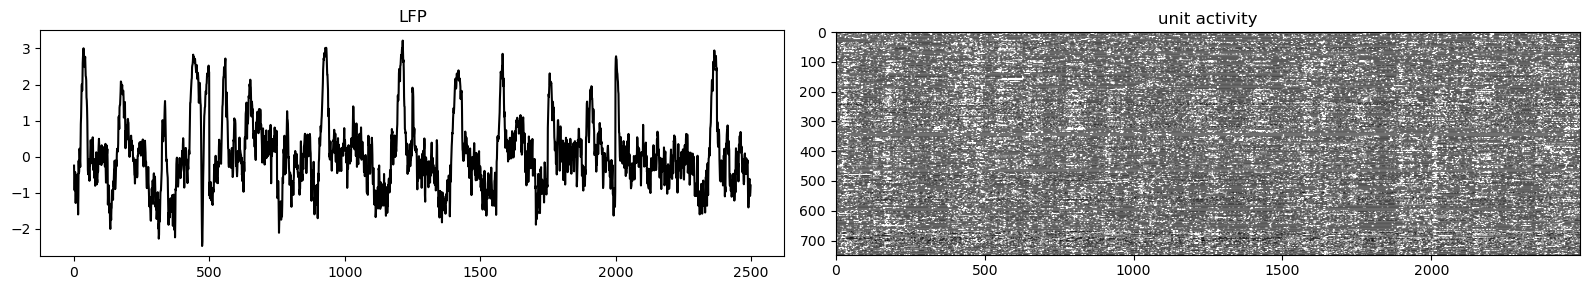

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(16, 3))

ax[0].plot(y_train[:int(10/bin_size)],'k',label='LFP')
ax[0].set_title('LFP')

ax[1].imshow(X_train[:int(10/bin_size),:].T, vmin=-1, vmax=1, cmap='gray')
ax[1].set_title('unit activity')

plt.tight_layout()
plt.show()

In [38]:
class Encoder(nn.Module):
    def __init__(self, input_size, num_hidden, num_layers, print=False):
        super(Encoder, self).__init__()
        self.print = print
        self.input_size = input_size
        self.num_hidden = num_hidden
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, num_hidden, num_layers, dropout=0.5)

    def forward(self, x):
        if self.print:
            print(f'Encoder Input: {list(x.shape)}')
        y, hidden = self.lstm(x)
        if self.print:
            print(f'Encoder RNN-out: {list(y.shape)}')
            print(f'Encoder RNN-hidden: {list(hidden[0].shape)}')
            print(f'Encoder RNN-cell: {list(hidden[1].shape)}')
        return y, hidden

class Decoder(nn.Module):
    def __init__(self, num_hidden, output_size, num_layers, print=False):
        super(Decoder, self).__init__()
        self.print = print
        self.num_hidden = num_hidden
        self.num_layers = num_layers
        self.lstm = nn.LSTM(output_size, num_hidden, num_layers, dropout=0.5)
        self.out = nn.Linear(num_hidden, output_size)

    def forward(self, x, hidden):
        if self.print:
            print(f'Decoder Input X: {list(x.shape)}')
            print(f'Decoder Input hidden: {list(hidden[0].shape)}')
            print(f'Decoder Input cell: {list(hidden[1].shape)}')
        y, hidden = self.lstm(x, hidden)
        if self.print:
            print(f'Decoder RNN-out: {list(y.shape)}')
            print(f'Decoder RNN-hidden: {list(hidden[0].shape)}')
            print(f'Decoder RNN-cell: {list(hidden[1].shape)}')
        o = self.out(y)
        if self.print:
            print(f'Decoder Output: {list(o.shape)}')
        return o, hidden

class Seq2Seq(nn.Module):
    def __init__(self, input_size, num_hidden, output_size, num_layers, print=False):
        super(Seq2Seq, self).__init__()
        self.encoder = Encoder(input_size, num_hidden, num_layers, print)
        self.decoder = Decoder(num_hidden, output_size, num_layers, print)
        self.print = print

    def forward(self, src, tgt, teacher_forcing_prob = 0.5):
        teacher_force = random.random() < teacher_forcing_prob
        encoder_output, hidden = self.encoder(src)
        decoder_output, _ = self.decoder(tgt, hidden)
        return decoder_output

In [39]:
# create an LSTM instance
net = Seq2Seq(input_size, hidden_size,output_size, num_layers, print = True)
print(net)
# test the model with some data
somedataX = X_trainT[:seqlength,:].view(seqlength,1,input_size)
somedataY = y_trainT[:seqlength].view(seqlength,1,1)

y  = net(somedataX, somedataY)

lossfun = nn.MSELoss()
lossfun(torch.squeeze(y), torch.squeeze(somedataY))

Seq2Seq(
  (encoder): Encoder(
    (lstm): LSTM(748, 20, dropout=0.5)
  )
  (decoder): Decoder(
    (lstm): LSTM(1, 20, dropout=0.5)
    (out): Linear(in_features=20, out_features=1, bias=True)
  )
)
Encoder Input: [125, 1, 748]
Encoder RNN-out: [125, 1, 20]
Encoder RNN-hidden: [1, 1, 20]
Encoder RNN-cell: [1, 1, 20]
Decoder Input X: [125, 1, 1]
Decoder Input hidden: [1, 1, 20]
Decoder Input cell: [1, 1, 20]
Decoder RNN-out: [125, 1, 20]
Decoder RNN-hidden: [1, 1, 20]
Decoder RNN-cell: [1, 1, 20]
Decoder Output: [125, 1, 1]


tensor(1.2825, grad_fn=<MseLossBackward0>)

In [ ]:
trg = torch.zeros(1, 1, 1)  # (sequence_length, batch_size, output_size)

# Forward pass through the encoder
with torch.no_grad():
    encoder_output, hidden = net.encoder(somedataX)

# Generate the output sequence step-by-step
output_sequence = []
decoder_input = trg

for _ in range(125):  # Generate a sequence of length 155
    with torch.no_grad():
        decoder_output, hidden = net.decoder(decoder_input, hidden)
    output_sequence.append(decoder_output)
    decoder_input = decoder_output  # Feed the output back as input

output_sequence = torch.cat(output_sequence, dim=0)
print(f"Inference output sequence length:{output_sequence.shape[0]}" )

Encoder Input: [125, 1, 748]
Encoder RNN-out: [125, 1, 20]
Encoder RNN-hidden: [1, 1, 20]
Encoder RNN-cell: [1, 1, 20]
Decoder Input X: [1, 1, 1]
Decoder Input hidden: [1, 1, 20]
Decoder Input cell: [1, 1, 20]
Decoder RNN-out: [1, 1, 20]
Decoder RNN-hidden: [1, 1, 20]
Decoder RNN-cell: [1, 1, 20]
Decoder Output: [1, 1, 1]
Decoder Input X: [1, 1, 1]
Decoder Input hidden: [1, 1, 20]
Decoder Input cell: [1, 1, 20]
Decoder RNN-out: [1, 1, 20]
Decoder RNN-hidden: [1, 1, 20]
Decoder RNN-cell: [1, 1, 20]
Decoder Output: [1, 1, 1]
Decoder Input X: [1, 1, 1]
Decoder Input hidden: [1, 1, 20]
Decoder Input cell: [1, 1, 20]
Decoder RNN-out: [1, 1, 20]
Decoder RNN-hidden: [1, 1, 20]
Decoder RNN-cell: [1, 1, 20]
Decoder Output: [1, 1, 1]
Decoder Input X: [1, 1, 1]
Decoder Input hidden: [1, 1, 20]
Decoder Input cell: [1, 1, 20]
Decoder RNN-out: [1, 1, 20]
Decoder RNN-hidden: [1, 1, 20]
Decoder RNN-cell: [1, 1, 20]
Decoder Output: [1, 1, 1]
Decoder Input X: [1, 1, 1]
Decoder Input hidden: [1, 1, 20]
D

In [11]:
def train(model_inp, numepochs = 10):
    lossfun = nn.MSELoss()
    N = y_train.shape[0]
    model_inp.to(device)
    optimizer = torch.optim.Adam(model_inp.parameters(),lr=.001, weight_decay=0.001)
    # initialize losses
    losses = np.zeros(numepochs)

    for epochi in range(numepochs):
      # loop over data segments
      seglosses = []
    
      for timei in range(0, N, seqlength):
        # grab a snippet of data
        X = X_trainT[timei:timei+seqlength,:].view(seqlength,1,input_size).to(device)
        y = y_trainT[timei:timei+seqlength].view(seqlength,1,1).to(device)
        # forward pass and loss
        yHat = model_inp(X,y)
        loss = lossfun(torch.squeeze(y), torch.squeeze(yHat))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        seglosses.append(loss.item())
      # average losses from this epoch
      losses[epochi] = np.mean(seglosses)
      msg = f'Finished epoch {epochi+1}/{numepochs}'
      sys.stdout.write('\r' + msg)
    return losses

In [ ]:
# input_size, num_hidden, output_size, num_layers
model = Seq2Seq(input_size,40,output_size, 5)

losses = train(model)

Finished epoch 10/10

Text(0.5, 1.0, 'Model loss')

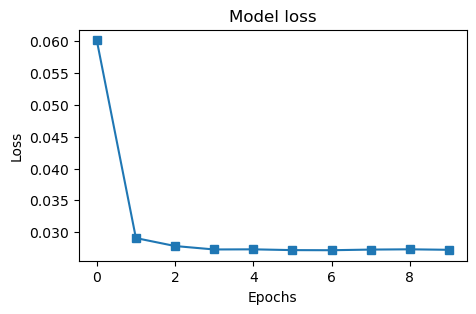

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(5,3))

ax.plot(losses,'s-')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Model loss')

In [20]:
def evaluate(model, X_data, y_data):
    model.eval()
    y_hat = np.zeros(y_data.shape[0])
    N = X_data.shape[0] - np.mod(X_data.shape[0], seqlength)
    with torch.no_grad():
        for timei in range(0, N, seqlength):
            X = X_data[timei:timei+seqlength, :].view(seqlength, 1, input_size).to(device)
            y = y_data[timei:timei+seqlength].view(seqlength,1,1).to(device)
            yy = model(X,y)
            y_hat[timei:timei+seqlength] = np.squeeze(yy.cpu().numpy())
    return y_hat

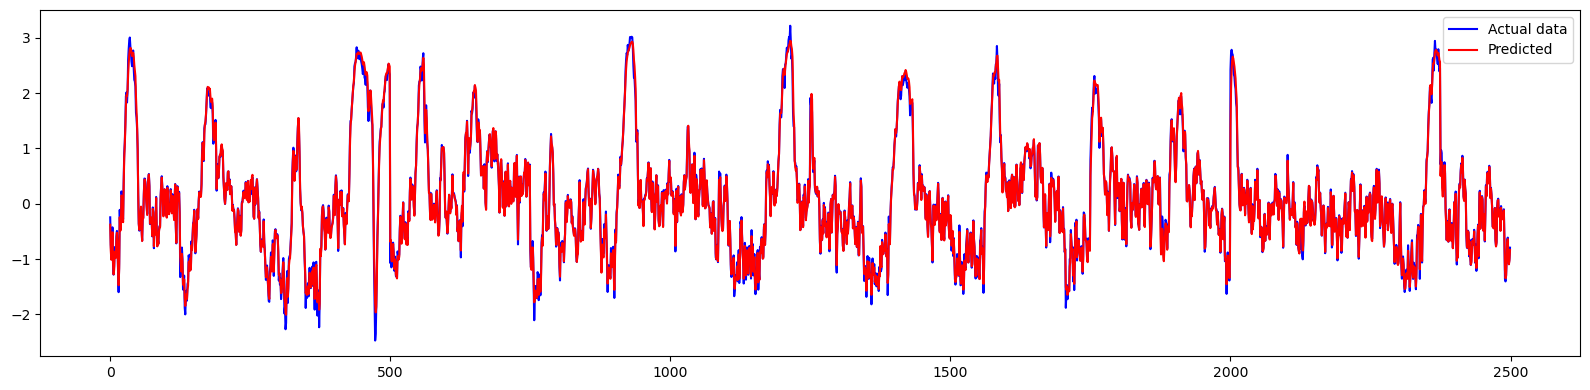

In [21]:
y_hat_train = evaluate(model, X_trainT, y_trainT)

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(y_train[:int(10/bin_size)],'b',label='Actual data')
# ax.plot(power_train[:int(10/bin_size),4],'b',label='Actual data')

ax.plot(y_hat_train[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()

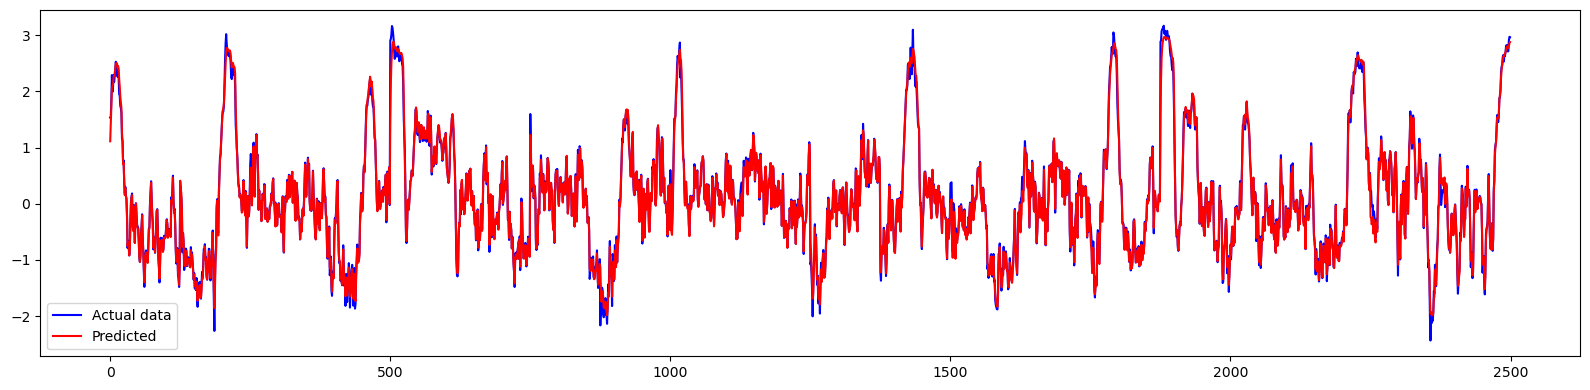

In [22]:
y_hat_test = evaluate(model, X_testT, y_testT)

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(y_test[:int(10/bin_size)],'b',label='Actual data')
# ax.plot(power_train[:int(10/bin_size),4],'b',label='Actual data')

ax.plot(y_hat_test[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()

In [29]:
def test(model, X_data):
    model.eval()
    y_hat = np.zeros(X_data.shape[0])
    N = X_data.shape[0] - np.mod(X_data.shape[0], seqlength)
    
    with torch.no_grad():
        for timei in range(0, N, seqlength):
            trg = torch.zeros(1, 1, 1).to(device) if timei == 0 else decoder_output
            X = X_data[timei:timei+seqlength, :].view(seqlength, 1, input_size).to(device)
            encoder_output, hidden = model.encoder(X)
            output_sequence = []
            decoder_input = trg
            for _ in range(seqlength):
                decoder_output, hidden = model.decoder(decoder_input, hidden)
                output_sequence.append(decoder_output)
                decoder_input = decoder_output
            y_hat[timei:timei+seqlength] = np.squeeze(decoder_output.cpu().numpy())
    return y_hat

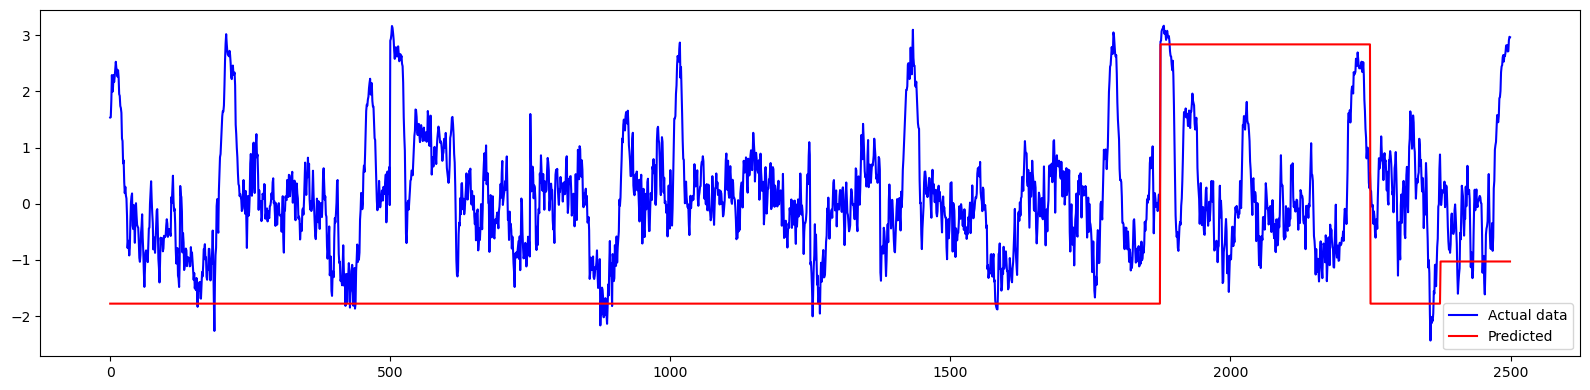

In [30]:
y_hat_test2 = test(model, X_testT[:int(10/bin_size),:])

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(y_test[:int(10/bin_size)],'b',label='Actual data')
# ax.plot(power_train[:int(10/bin_size),4],'b',label='Actual data')

ax.plot(y_hat_test2[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()